# Ontologies creation using NAIVE approaches

This notebook explores an initial approach to the challenge of ontology creation using large language models (LLMs). We will follow a simple heuristic to generate results and evaluate output:

1. **Input:** We start by providing a domain name and 5-10 terms related to the domain from which we wish to generate an ontology. This will expand to include a domain and topic, a definition for both, and eventually additional initial terms.
   
2. Given the input, we will request a large language model (in this case, ChatGPT-4o) to return a number (to be defined) of related terms.
   
3. Following initial thesis on calculation of semantic distance, we will request the model to calculate distance between terms. We will then test by removing or not removing terms with the lowest semantic distance and by requesting step 2 multiple times (distill).
   
4. Given the output of step 3, we will cluster results using hierarchical clustering.
   
5. Clusters will be used to serialize as RDF with a predicate "as-is" and the terms internally with "is-related". At this stage, we will also test requesting an LLM to generate text using the given terms and the domain/topic to test the extraction of different relations.
   
6. We will plot the ontology.
   
7. Compare the output with similar results from dbpedia.org.


### Prompts used for semantic distance calculations

Based out of initial work we will use the following prompts which have be shown to return good results. For this initial experiment we will only use english prompts to isolate tasks. we don't wish to analyse model capacity for task execution on a multi language environment.

```txt
In this survey you’ll be asked to rate quantitatively, on a scale, the intensity of the semantic relatedness between pairs of affective words. Please, before starting, read carefully the instructions and the examples provided. 

The question we’re asking is: how much related are the two words? Vaguely related words should be scored with lower values, and strongly related words with higher values. Please note that opposite words frequently present high values of relatedness.

For example, the words ’modest’ and ’smart’ don’t seem very related. ’Conceal’ and ’mask’ seem very related. ’Confident’ is highly related with itself. ’Violent’ and ’pacific’, being opposite words, are frequently related, just like ’happiness’ and ’sadness’. 

Examples: 
* modest, smart: 1,
* conceal, mask: 4 
* confident, confident: 5 
* violent, pacific: 4 
* happiness, sadness: 5

Please rate from 0 to 4 the semantic relatedness of the following pairs of words, with 0 indicating words not related at all and 4 indicating very related words: 
apple, galaxy
fault, system
champion, winner 
town, city

```

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import json
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src.services import ChatGpt
from src.services import clustering
from src.services import Ontology

---

## Experiment 3: 

**Description:** 

1. use a domain name and 10 terms related and request a term cloud. 
2. Request semantic distance between terms
3. No destil
4. Run hierarchy cluster
5. Create text out of terms
6. serialize into rdf

In [2]:
agent = ChatGpt()
agent.model = "gpt-4o-mini"

In [3]:
terms_list_str = agent.chat(
    instructions="You are a taxonomy and ontology expert. Provide concise and accurate responses based on the user's queries.",
    input="""
        Provide a list of 20 categories, terms or words closely related to domain or topic and using the provided terms as reference.
        
        - the domain or topic is: cinema
        - the provided terms are: 
            start trek, spoke, vulcan, klingon, enterprise
        
        Your output should be a json array with only the category names, without any additional text. 
        This categories should include the given terms and be closely related to the domain or topic.
        Do not encapsulate the output in code blocks.
        
        Example output:
        [
            "category1",
            "category2",
            ...            "category100"
        ]
        
    """
)

In [4]:
# Clean output. 
terms_list_json = json.loads(terms_list_str)
terms_list_df = pd.DataFrame(terms_list_json, columns=["category"])
print(terms_list_df.head(10))
print(terms_list_df.tail(10))

     category
0   Star Trek
1     Klingon
2      Vulcan
3  Enterprise
4   Starfleet
5      Phaser
6  Warp Drive
7  Federation
8        Borg
9     Romulan
                     category
10                   Holodeck
11                Transporter
12                   Starship
13  TNG (The Next Generation)
14            Original Series
15                      Spock
16                       Data
17                    Captain
18         Star Trek: Voyager
19                     Sci-Fi


In [5]:
# Cartesian product with provided terms
terms_pair = pd.merge(terms_list_df, terms_list_df, how='cross')
terms_pair = terms_pair.drop(terms_pair[terms_pair['category_x'] == terms_pair['category_y']].index) # We don't need to analyse a term with itself

In [6]:
## Calculate similarity for each pair
similarity_df = agent.get_similarity(terms_pair)

In [7]:
similarity_df.groupby("similarity").size().reset_index(name='counts')

,similarity,counts
0,2,61
1,3,122
2,4,195
3,5,2


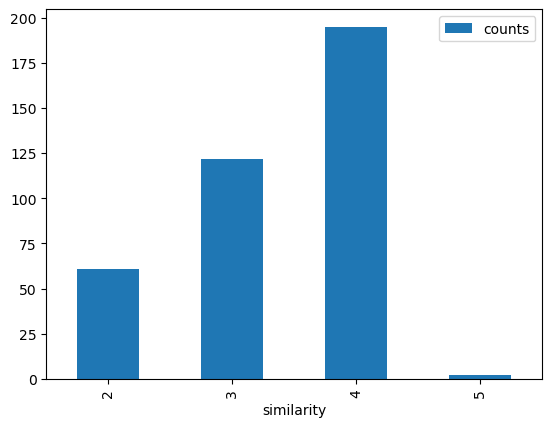

In [8]:
( 
    similarity_df
        .groupby("similarity")
        .size()
        .reset_index(name='counts')
        .plot(kind='bar', x='similarity', y='counts')
);

In [9]:
similarity_df['category_x'].unique()

array(['Star Trek', 'Klingon', 'Vulcan', 'Enterprise', 'Starfleet',
       'Phaser', 'Warp Drive', 'Federation', 'Borg', 'Romulan',
       'Holodeck', 'Transporter', 'Starship', 'TNG (The Next Generation)',
       'Original Series', 'Spock', 'Data', 'Captain',
       'Star Trek: Voyager', 'Sci-Fi'], dtype=object)

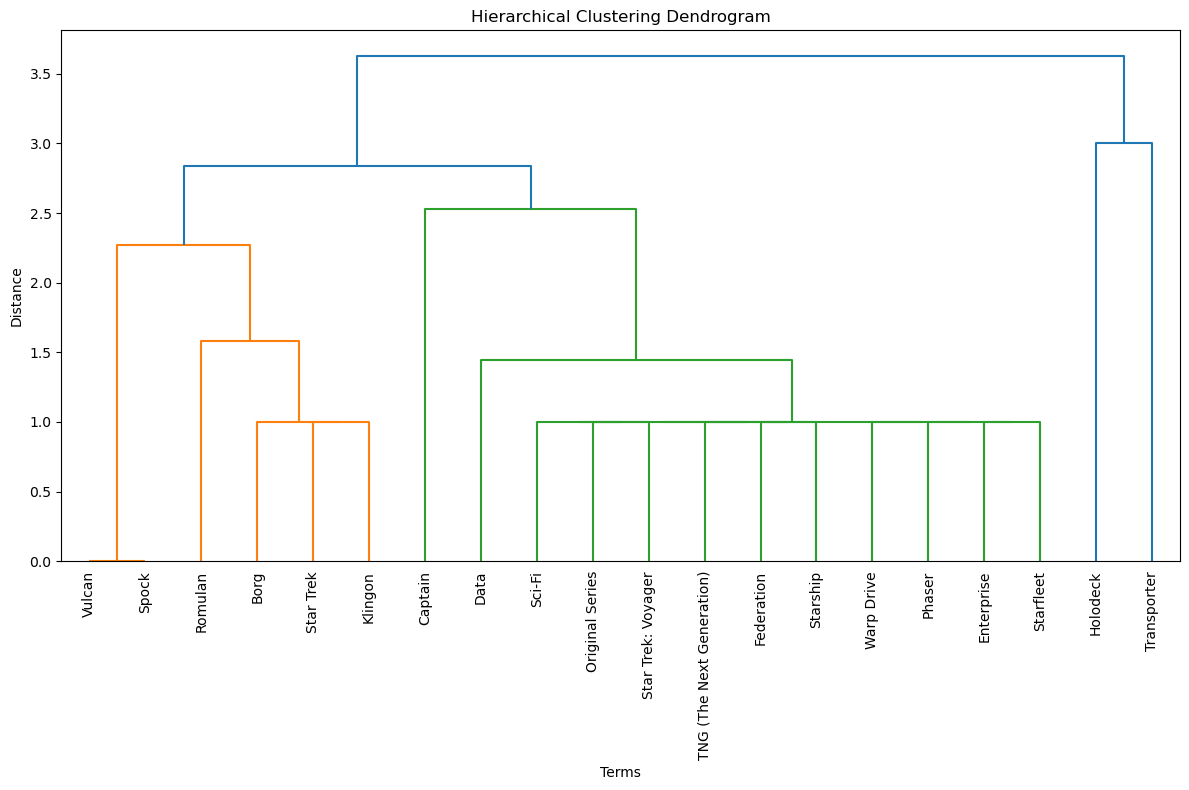

In [10]:
terms, distance_matrix, condensed_dist = clustering.create_distance_matrix(similarity_df, max_similarity = 5)

Z = linkage(condensed_dist, metric='euclidean', method="ward")

plt.figure(figsize=(12, 8))
dendrogram(Z, labels=terms, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Terms')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [11]:
# Extract clusters
distance_threshold = 1 # similar to a 3
clusters = fcluster(Z, t=distance_threshold, criterion='distance')
print(clusters)

[2 2 1 4 4 4 4 4 2 3 7 8 4 4 4 1 5 6 4 4]


In [12]:
cluster_df = pd.DataFrame({
    'term': terms,
    'cluster': clusters
})

cluster_df

,term,cluster
0,Star Trek,2
1,Klingon,2
2,Vulcan,1
3,Enterprise,4
4,Starfleet,4
5,Phaser,4
6,Warp Drive,4
7,Federation,4
8,Borg,2
9,Romulan,3


In [13]:
cluster_names = cluster_df.groupby('cluster')['term'].apply(agent.generate_cluster_name)
cluster_df['cluster_name'] = cluster_df['cluster'].map(cluster_names)
cluster_df

,term,cluster,cluster_name
0,Star Trek,2,Sci-Fi Species
1,Klingon,2,Sci-Fi Species
2,Vulcan,1,Star Trek Characters
3,Enterprise,4,Star Trek Universe
4,Starfleet,4,Star Trek Universe
5,Phaser,4,Star Trek Universe
6,Warp Drive,4,Star Trek Universe
7,Federation,4,Star Trek Universe
8,Borg,2,Sci-Fi Species
9,Romulan,3,Star Trek Faction


In [14]:
ontology = Ontology()
ontology.build_ontology(cluster_df)
ontology.serialize_ontology(format='turtle')

print(ontology.turtle)

@prefix ex: <http://example.org/ontology/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix related: <http://example.org/ontology/related/> .

ex:Captain rdfs:label "Captain" ;
    rdfs:subClassOf ex:Leadership .

ex:Data rdfs:label "Data" ;
    rdfs:subClassOf ex:Data_Types .

ex:Holodeck rdfs:label "Holodeck" ;
    rdfs:subClassOf ex:Virtual_Reality .

ex:Romulan rdfs:label "Romulan" ;
    rdfs:subClassOf ex:Star_Trek_Faction .

ex:Transporter rdfs:label "Transporter" ;
    rdfs:subClassOf ex:Transport_Systems .

ex:Spock rdfs:label "Spock" ;
    related:to ex:Vulcan ;
    rdfs:subClassOf ex:Star_Trek_Characters .

ex:Vulcan rdfs:label "Vulcan" ;
    related:to ex:Spock ;
    rdfs:subClassOf ex:Star_Trek_Characters .

ex:Borg rdfs:label "Borg" ;
    related:to ex:Klingon,
        ex:Star_Trek ;
    rdfs:subClassOf ex:Sci-Fi_Species .

ex:Klingon rdfs:label "Klingon" ;
    related:to ex:Borg,
        ex:Star_Trek ;
    rdfs:subClassOf ex:Sci-Fi_Species .

ex:Star_Trek

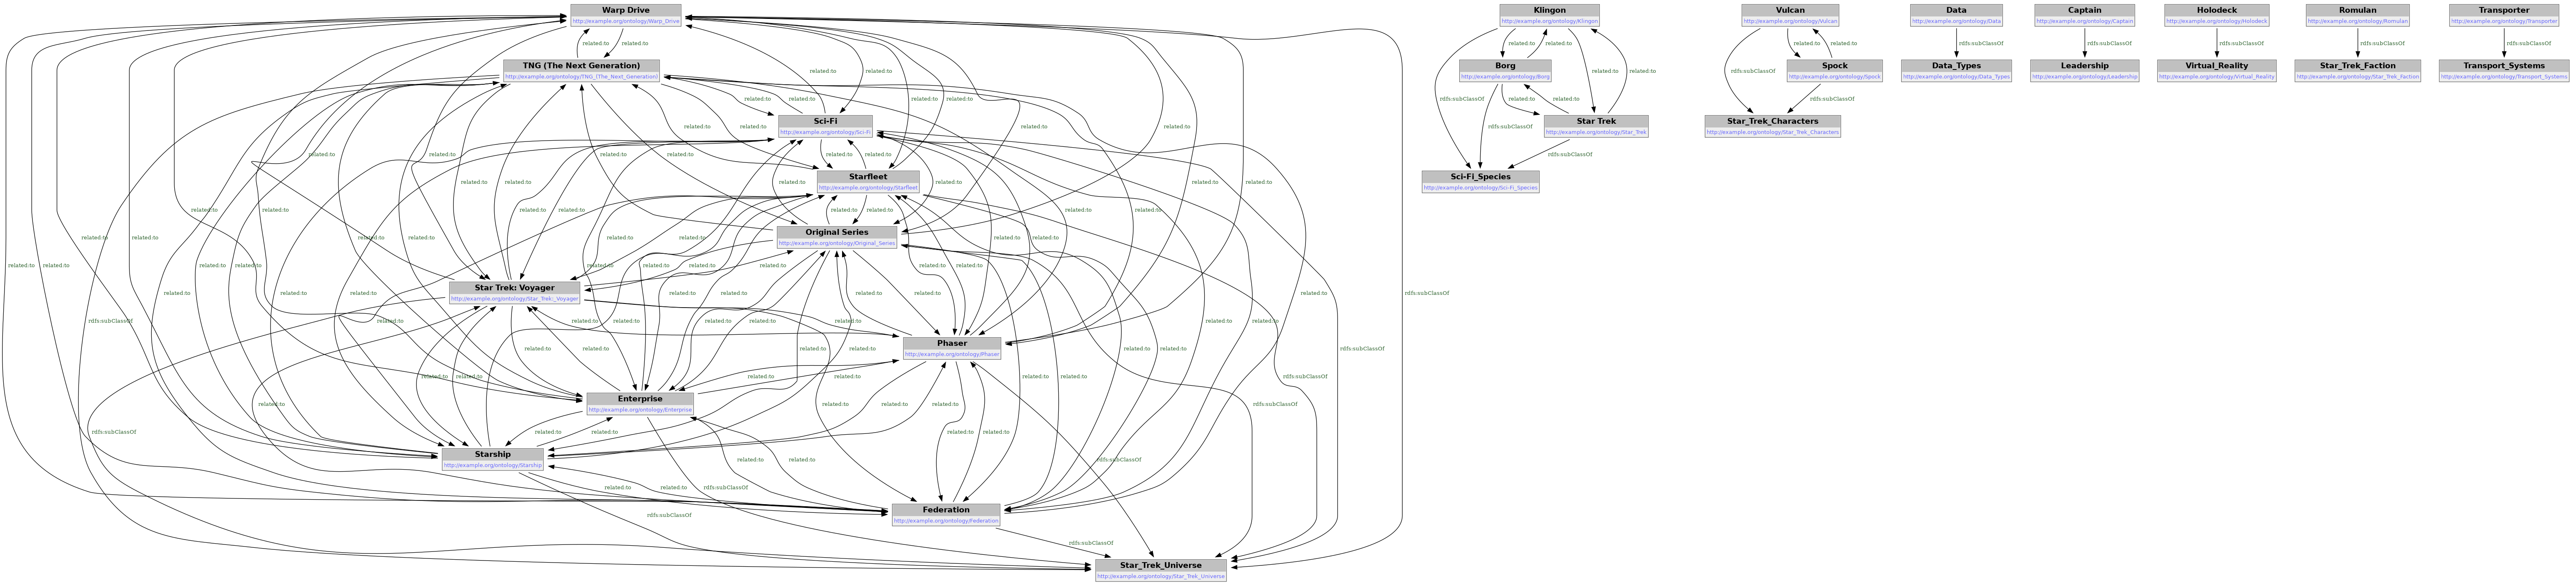

In [15]:
ontology.visualize()

In [31]:
terms =  cluster_df['term'].unique().tolist()

explain_text = agent.chat(
    instructions="You are a taxonomy and ontology expert. Provide concise and accurate responses based on the user's queries.",
    input=f"""
        Given a terms list write a short description for each potential relevant pair of terms in the list explaining the relationship between them.
        Only return text and nothing more and do not encapsulate the output in code blocks.
        
        example output:
        Leonard Simon Nimoy was born on March 26, 1931, in Boston, Massachusetts. 
        He was an American actor. He played Spock in Star Trek.
        
        terms list: {', '.join(terms)}.

    """
)

print(explain_text)

Star Trek is a seminal sci-fi franchise that encompasses various series, films, and media centered around space exploration and adventure. 

Klingon refers to a fictional alien species in Star Trek known for their warrior culture and honor-driven society, often in conflict with other species. 

Vulcan is another significant species in Star Trek, noted for their logical thinking and emotional control, with characters like Spock representing their culture. 

Enterprise is the name of several starships in Star Trek, most notably the USS Enterprise, which serves as the central vessel in many of the series, showcasing exploration missions and conflicts.

Starfleet is the exploratory and defensive service of the Federation in the Star Trek universe, consisting of various starships, including the Enterprise, and featuring officers like Captain Kirk and Spock.

Phaser is a standard-issue directed energy weapon used by Starfleet personnel in Star Trek for both combat and stun purposes.

Warp Dr

In [32]:
import spacy
from spacy import displacy

nlp = spacy.load("en_core_web_sm")
doc = nlp(explain_text)
displacy.render(doc, style='ent', jupyter=True)

In [ ]:
## Extract relationships between terms from the generated text

from collections import defaultdict

def extract_term_relationships(text, terms_list):
    doc = nlp(text)
    relationships = []
    
    terms_normalized = {term.lower(): term for term in terms_list}
    
    def find_term_spans(doc, terms_dict):
        term_spans = []
        for token in doc:
            for term_key, term_orig in terms_dict.items():
                # Check if token or its surrounding phrase matches a term
                if term_key in token.text.lower():
                    term_spans.append((token, term_orig))
                # Check for multi-word terms
                elif token.i < len(doc) - 1:
                    bigram = f"{token.text} {doc[token.i + 1].text}".lower()
                    if term_key in bigram:
                        term_spans.append((token, term_orig))
        return term_spans
    
    term_tokens = find_term_spans(doc, terms_normalized)
    
    for sent in doc.sents:
        for token in sent:
            # Look for verbs that connect our terms
            if token.pos_ == "VERB":
                subjects = [child for child in token.children if child.dep_ in ("nsubj", "nsubjpass")]
                objects = [child for child in token.children if child.dep_ in ("dobj", "pobj", "attr")]
                
                for subj in subjects:
                    for obj in objects:
                        subj_term = None
                        obj_term = None
                        
                        for term_token, term_name in term_tokens:
                            if term_token.sent == sent:
                                # Check if terms are in the subject or object subtree
                                if subj in term_token.ancestors or term_token in subj.subtree:
                                    subj_term = term_name
                                if obj in term_token.ancestors or term_token in obj.subtree:
                                    obj_term = term_name
                        
                        if subj_term and obj_term and subj_term != obj_term:
                            # Use lemmatized verb as predicate
                            predicate = token.lemma_
                            relationships.append({
                                'subject': subj_term,
                                'predicate': predicate,
                                'object': obj_term
                            })
    
    return pd.DataFrame(relationships)

# Extract relationships
relationships_df = extract_term_relationships(explain_text, terms)
print(f"Found {len(relationships_df)} relationships")
relationships_df

Found 1 relationships


,subject,predicate,object
0,Federation,refer,Star Trek


In [34]:
relationships = agent.chat(
    instructions="You are a taxonomy and ontology expert. Provide concise and accurate responses based on the user's queries.",
    input=f"""
        Given a terms list return the relationship between each potential relevant pair of terms in the list. 
        This should return in the form of rformat 'subject - predicate - object'.
        Only return text and nothing more and do not encapsulate the output in code blocks.
        
        terms list: {', '.join(terms)}.

    """
)

print(relationships)

Star Trek - includes - Klingon  
Star Trek - includes - Vulcan  
Star Trek - features - Enterprise  
Star Trek - features - Starfleet  
Starfleet - uses - Phaser  
Starfleet - utilizes - Warp Drive  
Federation - comprises - Starfleet  
Borg - are - antagonists  
Romulan - are - antagonists  
Star Trek - features - Holodeck  
Star Trek - features - Transporter  
Starship - is a type of - Starfleet vessel  
TNG (The Next Generation) - is a series in - Star Trek  
Original Series - is a series in - Star Trek  
Spock - is a character in - Star Trek  
Data - is a character in - Star Trek  
Captain - leads - Starship  
Star Trek: Voyager - is a series in - Star Trek  
Star Trek - belongs to - Sci-Fi genre  
